In [5]:
# ============================================================
# FULL PAPER-FAITHFUL TANet-TD3 (YOUR BOX ENV) — FIXED VERSION
#
# Fixes included:
# 1) Replay buffer transition FIX:
#    next_state stored AFTER per-step reassignment (assignment(t+1))
# 2) Gym -> Gymnasium (removes warning)
# 3) Exploration noise FIX (scaled by max_action):
#    noise_std = exploration_noise * max_action
# 4) env.step returns CANONICAL obs (assigned_first=False);
#    trainer builds re-sequenced obs AFTER assignment each step
# 5) Assignment sanity checks (no duplicate targets)
# 6) Ctrl+C interrupt saves checkpoint; resume supported
# ============================================================

import copy
import csv
import time
import numpy as np

import gymnasium as gym
from gymnasium import spaces

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from scipy.optimize import linear_sum_assignment


# ============================================================
# ENVIRONMENT (paper-faithful sensing: relative + detection-limited)
# ============================================================

class UAVBox3D_TANetTD3_Env(gym.Env):
    """
    Observation dim:
      obs_dim = 7 + 4(NU-1) + 4NT + 7NO
        sui:       [pos3, vel3, ru]                         -> 7
        others:    for each other uav [dx,dy,dz,dist]        -> 4*(NU-1)
        targets:   for each target [dtx,dty,dtz,rt_eff]      -> 4*NT (RELATIVE)
        obstacles: for each obstacle (detection-limited)
                   [dox,doy,doz,ro_eff,dbox,in_det,pad]      -> 7*NO

    Trainer will use:
      - TANet input: canonical ordering (assigned_first=False)
      - TD3 input: re-sequenced ordering (assigned_first=True) where assigned target is first
    """

    metadata = {"render_modes": []}

    def __init__(
        self,
        seed=0,
        max_steps=100,
        n_uavs=4,
        n_targets=4,
        n_obstacles=2,

        # paper-like parameters
        ru=0.02,
        d_det=0.5,
        max_velocity=0.05,

        # box geometry
        obs_half_xy=np.array([0.20, 0.20], dtype=np.float32),
        target_half_xy=np.array([0.08, 0.08], dtype=np.float32),
        obs_height_range=(0.4, 0.9),
        target_height_range=(0.3, 0.7),

        # world bounds
        world_low=np.array([-1.0, -1.0, 0.0], dtype=np.float32),
        world_high=np.array([1.0, 1.0, 1.0], dtype=np.float32),

        # clearances
        min_extra_clearance=0.05,
        spawn_margin=0.05,
        max_spawn_tries=50000,
    ):
        super().__init__()
        self.rng = np.random.default_rng(seed)

        self.n_uavs = int(n_uavs)
        self.n_targets = int(n_targets)
        self.n_obstacles = int(n_obstacles)
        self.max_steps = int(max_steps)

        self.ru = float(ru)
        self.d_det = float(d_det)
        self.max_velocity = float(max_velocity)

        self.obs_half_xy = obs_half_xy.astype(np.float32)
        self.target_half_xy = target_half_xy.astype(np.float32)
        self.obs_height_range = tuple(obs_height_range)
        self.target_height_range = tuple(target_height_range)

        self.world_low = world_low.astype(np.float32)
        self.world_high = world_high.astype(np.float32)

        self.min_extra_clearance = float(min_extra_clearance)
        self.spawn_margin = float(spawn_margin)
        self.max_spawn_tries = int(max_spawn_tries)

        # Effective radii (approx) used for completion/safe thresholds
        self.rt_eff = float(np.linalg.norm(
            np.array([
                self.target_half_xy[0],
                self.target_half_xy[1],
                0.25 * (self.target_height_range[0] + self.target_height_range[1])
            ], dtype=np.float32)
        ))
        self.ro_eff = float(np.linalg.norm(
            np.array([
                self.obs_half_xy[0],
                self.obs_half_xy[1],
                0.25 * (self.obs_height_range[0] + self.obs_height_range[1])
            ], dtype=np.float32)
        ))

        # State
        self.uav_pos = None
        self.uav_vel = None
        self.tgt_pos = None
        self.obs_pos = None
        self.obs_half_z = None
        self.target_half_z = None
        self.assigned = None
        self.reached = None
        self.step_count = 0

        # Metrics
        self.ep_dist = None
        self.coll_uav_uav = 0
        self.coll_uav_obs = 0
        self.coll_uav_other_tgt = 0
        self.finish_step_per_uav = None

        obs_dim = 7 + 4 * (self.n_uavs - 1) + 4 * self.n_targets + 7 * self.n_obstacles

        # Multi-agent consistent spaces (Tuple)
        one_obs_space = spaces.Box(-10.0, 10.0, shape=(obs_dim,), dtype=np.float32)
        one_act_space = spaces.Box(
            low=-self.max_velocity, high=self.max_velocity, shape=(3,), dtype=np.float32
        )
        self.observation_space = spaces.Tuple([one_obs_space for _ in range(self.n_uavs)])
        self.action_space = spaces.Tuple([one_act_space for _ in range(self.n_uavs)])

    # ----------------------------
    # Geometry helpers
    # ----------------------------
    @staticmethod
    def _aabb_distance(p, c, half_xyz):
        d = np.abs(p - c) - half_xyz
        d = np.maximum(d, 0.0)
        return float(np.linalg.norm(d))

    def _sample_boxes_xy_height(self, n, half_xy, h_range,
                                avoid_centers=None, avoid_half_xy=None, avoid_half_z=None):
        centers, half_z = [], []
        tries = 0

        low_xy = self.world_low[:2] + half_xy
        high_xy = self.world_high[:2] - half_xy

        while len(centers) < n:
            tries += 1
            if tries > self.max_spawn_tries:
                raise RuntimeError("Sampling failed. Relax sizes/clearance or reduce counts.")

            xy = self.rng.uniform(low_xy, high_xy).astype(np.float32)
            h = float(self.rng.uniform(*h_range))
            hz = h / 2.0
            zc = hz  # grounded
            c = np.array([xy[0], xy[1], zc], dtype=np.float32)

            ok = True

            # same-type separation in XY
            for e in centers:
                if np.linalg.norm(c[:2] - e[:2]) < (2.0 * np.linalg.norm(half_xy) + self.min_extra_clearance):
                    ok = False
                    break

            # avoid other-type in XY
            if ok and avoid_centers is not None:
                for ac, ahz in zip(avoid_centers, avoid_half_z):
                    if np.linalg.norm(c[:2] - ac[:2]) < (
                        np.linalg.norm(half_xy) + np.linalg.norm(avoid_half_xy) + self.min_extra_clearance
                    ):
                        ok = False
                        break

            if ok:
                centers.append(c)
                half_z.append(hz)

        return np.array(centers, dtype=np.float32), np.array(half_z, dtype=np.float32)

    def _spawn_uavs_with_clearance(self):
        uavs = []
        tries = 0

        while len(uavs) < self.n_uavs:
            tries += 1
            if tries > self.max_spawn_tries:
                raise RuntimeError("UAV spawn failed. Relax spawn_margin or reduce sizes/counts.")

            p = self.rng.uniform(self.world_low, self.world_high).astype(np.float32)
            p = np.clip(p, self.world_low, self.world_high)

            ok = True

            # avoid obstacles
            for o in range(self.n_obstacles):
                half_xyz = np.array([self.obs_half_xy[0], self.obs_half_xy[1], self.obs_half_z[o]], dtype=np.float32)
                dbox = self._aabb_distance(p, self.obs_pos[o], half_xyz)
                if dbox <= (self.ru + self.spawn_margin):
                    ok = False
                    break
            if not ok:
                continue

            # avoid targets (prevent trivial success)
            for t in range(self.n_targets):
                d = float(np.linalg.norm(p - self.tgt_pos[t]))
                if d <= (self.ru + self.rt_eff + self.spawn_margin):
                    ok = False
                    break
            if not ok:
                continue

            # avoid other UAVs
            for q in uavs:
                if float(np.linalg.norm(p - q)) <= (2.0 * self.ru + self.spawn_margin):
                    ok = False
                    break

            if ok:
                uavs.append(p)

        return np.stack(uavs, axis=0).astype(np.float32)

    # ----------------------------
    # Reset
    # ----------------------------
    def reset(self, seed=None, options=None):
        if seed is not None:
            self.rng = np.random.default_rng(seed)

        self.step_count = 0

        # obstacles first
        self.obs_pos, self.obs_half_z = self._sample_boxes_xy_height(
            self.n_obstacles, self.obs_half_xy, self.obs_height_range
        )

        # targets avoid obstacles
        self.tgt_pos, self.target_half_z = self._sample_boxes_xy_height(
            self.n_targets, self.target_half_xy, self.target_height_range,
            avoid_centers=self.obs_pos, avoid_half_xy=self.obs_half_xy, avoid_half_z=self.obs_half_z
        )

        # UAVs with clearance
        self.uav_pos = self._spawn_uavs_with_clearance()
        self.uav_vel = np.zeros((self.n_uavs, 3), dtype=np.float32)

        # initial assignment (placeholder; trainer will overwrite via TANet/Hungarian)
        perm = self.rng.permutation(self.n_targets)
        self.assigned = perm[:self.n_uavs].astype(int)

        self.reached = np.zeros(self.n_uavs, dtype=bool)

        # metrics
        self.ep_dist = np.zeros(self.n_uavs, dtype=np.float32)
        self.coll_uav_uav = 0
        self.coll_uav_obs = 0
        self.coll_uav_other_tgt = 0
        self.finish_step_per_uav = -np.ones(self.n_uavs, dtype=int)

        obs = [self._obs_i(i, assigned_first=False) for i in range(self.n_uavs)]
        info = {"assigned": self.assigned.copy()}
        return obs, info

    # ----------------------------
    # Observation
    # ----------------------------
    def _obs_i(self, i, assigned_first=True, forced_target_first=None):
        # sui
        sui = np.concatenate(
            [self.uav_pos[i], self.uav_vel[i], np.array([self.ru], dtype=np.float32)],
            axis=0
        )

        # other uavs: relative + dist
        others = []
        for k in range(self.n_uavs):
            if k == i:
                continue
            dvec = (self.uav_pos[k] - self.uav_pos[i]).astype(np.float32)
            dist = float(np.linalg.norm(dvec))
            others.append(np.concatenate([dvec, np.array([dist], dtype=np.float32)], axis=0))
        others_flat = np.concatenate(others, axis=0).astype(np.float32)

        # targets: RELATIVE vectors
        tgt_feats = []
        for j in range(self.n_targets):
            rel_t = (self.tgt_pos[j] - self.uav_pos[i]).astype(np.float32)
            tgt_feats.append(np.concatenate([rel_t, np.array([self.rt_eff], dtype=np.float32)], axis=0))
        tgt_feats = np.stack(tgt_feats, axis=0).astype(np.float32)  # (NT,4)

        # reorder so chosen target is first (new sequence)
        if assigned_first:
            first = int(forced_target_first) if forced_target_first is not None else int(self.assigned[i])
            order = [first] + [j for j in range(self.n_targets) if j != first]
            tgt_feats = tgt_feats[order]

        tgt_flat = tgt_feats.reshape(-1).astype(np.float32)

        # obstacles: detection-limited
        obs_feats = []
        for o in range(self.n_obstacles):
            half_xyz = np.array([self.obs_half_xy[0], self.obs_half_xy[1], self.obs_half_z[o]], dtype=np.float32)
            dbox = self._aabb_distance(self.uav_pos[i], self.obs_pos[o], half_xyz)

            if dbox < self.d_det:
                rel_o = (self.obs_pos[o] - self.uav_pos[i]).astype(np.float32)
                obs_feats.append(np.array([
                    rel_o[0], rel_o[1], rel_o[2],
                    self.ro_eff, dbox, 1.0, 1.0
                ], dtype=np.float32))
            else:
                sgn = np.sign(self.uav_pos[i] - self.obs_pos[o]).astype(np.float32)
                sgn[sgn == 0] = 1.0
                ph = (sgn * self.d_det).astype(np.float32)
                obs_feats.append(np.array([
                    ph[0], ph[1], ph[2],
                    self.ro_eff, dbox, 0.0, 1.0
                ], dtype=np.float32))

        obs_flat = np.concatenate(obs_feats, axis=0).astype(np.float32)

        return np.concatenate([sui, others_flat, tgt_flat, obs_flat], axis=0).astype(np.float32)

    # ----------------------------
    # Step (reward uses CURRENT assignment)
    # Gymnasium API: returns (obs, reward, terminated, truncated, info)
    # We keep "global done" semantics and broadcast per-agent arrays.
    # ----------------------------
    def step(self, actions):
        self.step_count += 1

        actions = np.asarray(actions, dtype=np.float32)
        actions = np.clip(actions, -self.max_velocity, self.max_velocity)

        prev_pos = self.uav_pos.copy()

        # move UAVs
        for i in range(self.n_uavs):
            if self.reached[i]:
                self.uav_vel[i] = 0.0
                continue
            self.uav_vel[i] = actions[i]
            self.uav_pos[i] = np.clip(self.uav_pos[i] + actions[i], self.world_low, self.world_high)

        # distance metric
        step_disp = np.linalg.norm(self.uav_pos - prev_pos, axis=1).astype(np.float32)
        self.ep_dist += step_disp

        rewards = np.zeros(self.n_uavs, dtype=np.float32)

        # UAV-UAV collisions
        for i in range(self.n_uavs):
            for k in range(i + 1, self.n_uavs):
                d = float(np.linalg.norm(self.uav_pos[i] - self.uav_pos[k]))
                if d <= (2.0 * self.ru):
                    self.coll_uav_uav += 1
                    if not self.reached[i]:
                        rewards[i] += -1.0
                    if not self.reached[k]:
                        rewards[k] += -1.0

        d_safe_obs = self.ru + self.ro_eff

        for i in range(self.n_uavs):
            if self.reached[i]:
                continue

            j = int(self.assigned[i])

            # target shaping (paper form): 0 if reached else -distance
            d_t = float(np.linalg.norm(self.uav_pos[i] - self.tgt_pos[j]))
            if d_t < (self.ru + self.rt_eff):
                rewards[i] += 0.0
                self.reached[i] = True
                self.finish_step_per_uav[i] = int(self.step_count)
            else:
                rewards[i] += -d_t

            # obstacle penalty only within d_det
            d_list = []
            for o in range(self.n_obstacles):
                half_xyz = np.array([self.obs_half_xy[0], self.obs_half_xy[1], self.obs_half_z[o]], dtype=np.float32)
                d_list.append(self._aabb_distance(self.uav_pos[i], self.obs_pos[o], half_xyz))
            d_min = float(np.min(d_list)) if len(d_list) else float("inf")

            if d_min < self.d_det:
                if d_min <= d_safe_obs:
                    rewards[i] += -1.0
                    self.coll_uav_obs += 1
                else:
                    rewards[i] += -(self.d_det - d_min)

            # metric: entering other targets' AABB
            for t2 in range(self.n_targets):
                if t2 == j:
                    continue
                half_xyz_t = np.array(
                    [self.target_half_xy[0], self.target_half_xy[1], self.target_half_z[t2]],
                    dtype=np.float32
                )
                if self._aabb_distance(self.uav_pos[i], self.tgt_pos[t2], half_xyz_t) == 0.0:
                    self.coll_uav_other_tgt += 1
                    break

        done_all = bool(np.all(self.reached))
        time_up = (self.step_count >= self.max_steps)

        terminated = done_all
        truncated = (time_up and (not done_all))

        info = {
            "assigned": self.assigned.copy(),
            "reached": self.reached.copy(),
            "ep_dist": self.ep_dist.copy(),
            "coll_uav_uav": int(self.coll_uav_uav),
            "coll_uav_obs": int(self.coll_uav_obs),
            "coll_uav_other_tgt": int(self.coll_uav_other_tgt),
            "finish_step_per_uav": self.finish_step_per_uav.copy(),
            "done_all": bool(done_all),
            "time_up": bool(time_up),
            "step": int(self.step_count),
            "success_ratio": float(np.mean(self.reached)),
        }

        # IMPORTANT: return CANONICAL obs; trainer will re-sequence after reassignment
        obs = [self._obs_i(i, assigned_first=False) for i in range(self.n_uavs)]
        return obs, rewards, terminated, truncated, info


# ============================================================
# TD3
# ============================================================

class Actor64_128_64(nn.Module):
    def __init__(self, state_dim, action_dim, max_action):
        super().__init__()
        self.fc1 = nn.Linear(state_dim, 64)
        self.fc2 = nn.Linear(64, 128)
        self.fc3 = nn.Linear(128, 64)
        self.out = nn.Linear(64, action_dim)
        self.max_action = float(max_action)

    def forward(self, s):
        x = F.relu(self.fc1(s))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        a = torch.tanh(self.out(x))
        return a * self.max_action


class Critic64_128_64(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.q1_fc1 = nn.Linear(state_dim + action_dim, 64)
        self.q1_fc2 = nn.Linear(64, 128)
        self.q1_fc3 = nn.Linear(128, 64)
        self.q1_out = nn.Linear(64, 1)

        self.q2_fc1 = nn.Linear(state_dim + action_dim, 64)
        self.q2_fc2 = nn.Linear(64, 128)
        self.q2_fc3 = nn.Linear(128, 64)
        self.q2_out = nn.Linear(64, 1)

    def forward(self, s, a):
        sa = torch.cat([s, a], dim=1)

        q1 = F.relu(self.q1_fc1(sa))
        q1 = F.relu(self.q1_fc2(q1))
        q1 = F.relu(self.q1_fc3(q1))
        q1 = self.q1_out(q1)

        q2 = F.relu(self.q2_fc1(sa))
        q2 = F.relu(self.q2_fc2(q2))
        q2 = F.relu(self.q2_fc3(q2))
        q2 = self.q2_out(q2)

        return q1, q2

    def Q1(self, s, a):
        sa = torch.cat([s, a], dim=1)
        q1 = F.relu(self.q1_fc1(sa))
        q1 = F.relu(self.q1_fc2(q1))
        q1 = F.relu(self.q1_fc3(q1))
        return self.q1_out(q1)


class ReplayBuffer:
    def __init__(self, state_dim, action_dim, max_size=int(5e5)):
        self.max_size = int(max_size)
        self.ptr = 0
        self.size = 0
        self.s = np.zeros((self.max_size, state_dim), dtype=np.float32)
        self.a = np.zeros((self.max_size, action_dim), dtype=np.float32)
        self.ns = np.zeros((self.max_size, state_dim), dtype=np.float32)
        self.r = np.zeros((self.max_size, 1), dtype=np.float32)
        self.d = np.zeros((self.max_size, 1), dtype=np.float32)

    def add(self, s, a, r, ns, d):
        self.s[self.ptr] = s
        self.a[self.ptr] = a
        self.r[self.ptr] = r
        self.ns[self.ptr] = ns
        self.d[self.ptr] = d
        self.ptr = (self.ptr + 1) % self.max_size
        self.size = min(self.size + 1, self.max_size)

    def sample(self, batch_size):
        idx = np.random.randint(0, self.size, size=int(batch_size))
        return (
            torch.FloatTensor(self.s[idx]),
            torch.FloatTensor(self.a[idx]),
            torch.FloatTensor(self.r[idx]),
            torch.FloatTensor(self.ns[idx]),
            torch.FloatTensor(self.d[idx]),
        )


class TD3Agent:
    def __init__(
        self,
        state_dim,
        action_dim,
        max_action,
        discount=0.9,
        tau=0.01,
        actor_lr=1e-4,
        critic_lr=1e-3,
        policy_noise=0.2,
        noise_clip=0.5,
        policy_freq=2,
        device=None
    ):
        if device is None:
            device = "cuda" if torch.cuda.is_available() else "cpu"
        self.device = torch.device(device)

        self.actor = Actor64_128_64(state_dim, action_dim, max_action).to(self.device)
        self.actor_t = copy.deepcopy(self.actor).to(self.device)
        self.actor_opt = optim.Adam(self.actor.parameters(), lr=actor_lr)

        self.critic = Critic64_128_64(state_dim, action_dim).to(self.device)
        self.critic_t = copy.deepcopy(self.critic).to(self.device)
        self.critic_opt = optim.Adam(self.critic.parameters(), lr=critic_lr)

        self.max_action = float(max_action)
        self.discount = float(discount)
        self.tau = float(tau)

        self.policy_noise = float(policy_noise)
        self.noise_clip = float(noise_clip)
        self.policy_freq = int(policy_freq)
        self.total_it = 0

    @torch.no_grad()
    def act(self, s, noise_scale=0.0):
        """
        FIX: noise_scale is interpreted as a FRACTION of max_action
             noise_std = noise_scale * max_action
        """
        s = torch.FloatTensor(s).unsqueeze(0).to(self.device)
        a = self.actor(s).cpu().numpy().flatten()

        if noise_scale > 0:
            a = a + np.random.normal(
                loc=0.0,
                scale=noise_scale * self.max_action,   # <-- FIXED scaling
                size=a.shape
            ).astype(np.float32)

        return np.clip(a, -self.max_action, self.max_action).astype(np.float32)

    def train(self, rb: ReplayBuffer, batch_size=256):
        if rb.size < batch_size:
            return

        self.total_it += 1

        s, a, r, ns, d = rb.sample(batch_size)
        s = s.to(self.device)
        a = a.to(self.device)
        r = r.to(self.device)
        ns = ns.to(self.device)
        d = d.to(self.device)

        with torch.no_grad():
            noise = (torch.randn_like(a) * self.policy_noise).clamp(-self.noise_clip, self.noise_clip)
            na = (self.actor_t(ns) + noise).clamp(-self.max_action, self.max_action)

            tq1, tq2 = self.critic_t(ns, na)
            tq = torch.min(tq1, tq2)
            y = r + (1.0 - d) * self.discount * tq

        cq1, cq2 = self.critic(s, a)
        critic_loss = F.mse_loss(cq1, y) + F.mse_loss(cq2, y)

        self.critic_opt.zero_grad()
        critic_loss.backward()
        self.critic_opt.step()

        if self.total_it % self.policy_freq == 0:
            actor_loss = -self.critic.Q1(s, self.actor(s)).mean()

            self.actor_opt.zero_grad()
            actor_loss.backward()
            self.actor_opt.step()

            # soft updates
            for p, tp in zip(self.critic.parameters(), self.critic_t.parameters()):
                tp.data.copy_(self.tau * p.data + (1.0 - self.tau) * tp.data)
            for p, tp in zip(self.actor.parameters(), self.actor_t.parameters()):
                tp.data.copy_(self.tau * p.data + (1.0 - self.tau) * tp.data)


# ============================================================
# TANet + Hungarian
# ============================================================

class TargetAssignmentNet(nn.Module):
    def __init__(self, input_dim, n_targets):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.fc2 = nn.Linear(64, 128)
        self.fc3 = nn.Linear(128, 64)
        self.out = nn.Linear(64, n_targets)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        return self.out(x)  # logits


def hungarian_from_scores(scores, maximize=True):
    cost = -scores if maximize else scores
    rows, cols = linear_sum_assignment(cost)
    mapping = {int(r): int(c) for r, c in zip(rows, cols)}
    labels = np.zeros(scores.shape, dtype=np.float32)
    for i, j in mapping.items():
        labels[i, j] = 1.0
    return mapping, labels


def apply_mapping_to_env(env, mapping):
    for i in range(env.n_uavs):
        env.assigned[i] = int(mapping[i])

    # sanity checks (catch real assignment bugs)
    a = env.assigned
    assert np.all((a >= 0) & (a < env.n_targets)), "BUG: assigned target out of range"
    assert len(set(map(int, a))) == env.n_uavs, "BUG: duplicate targets assigned"


def build_resequenced_obs(env):
    return [env._obs_i(i, assigned_first=True) for i in range(env.n_uavs)]


@torch.no_grad()
def compute_Q_matrix_fast(agents, env):
    """
    For each UAV i and candidate target j:
      evaluate Q(s~_{i,j}, actor(s~_{i,j})) where s~ puts target j first.
    Does NOT mutate env.assigned.
    """
    NU = env.n_uavs
    NT = env.n_targets
    Q = np.zeros((NU, NT), dtype=np.float32)

    for i in range(NU):
        for j in range(NT):
            s_tilde = env._obs_i(i, assigned_first=True, forced_target_first=j)
            s_t = torch.FloatTensor(s_tilde).unsqueeze(0).to(agents[i].device)
            a_t = agents[i].actor(s_t)
            q1, q2 = agents[i].critic(s_t, a_t)
            Q[i, j] = torch.min(q1, q2).item()

    return Q


# ============================================================
# CHECKPOINT SAVE/LOAD
# ============================================================

def save_tanet_td3_checkpoint(path, agents, tanet, tanet_opt=None, extra=None):
    ckpt = {
        "agents": [
            {
                "actor": ag.actor.state_dict(),
                "actor_t": ag.actor_t.state_dict(),
                "actor_opt": ag.actor_opt.state_dict(),
                "critic": ag.critic.state_dict(),
                "critic_t": ag.critic_t.state_dict(),
                "critic_opt": ag.critic_opt.state_dict(),
                "total_it": int(getattr(ag, "total_it", 0)),
            }
            for ag in agents
        ],
        "tanet": tanet.state_dict(),
        "tanet_opt": tanet_opt.state_dict() if tanet_opt is not None else None,
        "extra": extra if extra is not None else {},
    }
    torch.save(ckpt, path)
    print(f"Saved checkpoint -> {path}", flush=True)


def load_tanet_td3_checkpoint(path, agents, tanet, tanet_opt=None, device=None):
    ckpt = torch.load(path, map_location=device if device is not None else "cpu")

    assert len(ckpt["agents"]) == len(agents), "Checkpoint agent count mismatch."
    for ag, ag_ckpt in zip(agents, ckpt["agents"]):
        ag.actor.load_state_dict(ag_ckpt["actor"])
        ag.actor_t.load_state_dict(ag_ckpt["actor_t"])
        ag.actor_opt.load_state_dict(ag_ckpt["actor_opt"])

        ag.critic.load_state_dict(ag_ckpt["critic"])
        ag.critic_t.load_state_dict(ag_ckpt["critic_t"])
        ag.critic_opt.load_state_dict(ag_ckpt["critic_opt"])

        ag.total_it = int(ag_ckpt.get("total_it", 0))

    tanet.load_state_dict(ckpt["tanet"])
    if tanet_opt is not None and ckpt.get("tanet_opt") is not None:
        tanet_opt.load_state_dict(ckpt["tanet_opt"])

    return ckpt.get("extra", {})


# ============================================================
# TRAIN (paper-faithful: assignment every step)
# ============================================================

def train_TANet_TD3_paper_style(
    seed=0,
    episodes=2000,
    max_steps=100,
    exploration_noise=0.2,   # interpreted as FRACTION of max_action (fixed)
    batch_size=256,
    tanet_lr=1e-3,
    device=None,
    train_csv="tanet_td3_train_log.csv",
    print_every=50,

    ckpt_path="tanet_td3_baseline.pth",
    save_every=200,

    resume_path=None,
    append_csv=True,

    td3_updates_per_step=1,
):
    env = UAVBox3D_TANetTD3_Env(
        seed=seed,
        max_steps=max_steps,
        n_uavs=4,
        n_targets=4,
        n_obstacles=2,
        d_det=0.5,
        world_low=np.array([-1.0, -1.0, 0.0], dtype=np.float32),
        world_high=np.array([1.0, 1.0, 1.0], dtype=np.float32),
    )

    _obs0, _ = env.reset(seed=seed)

    state_dim = env.observation_space[0].shape[0]
    action_dim = env.action_space[0].shape[0]
    max_action = float(env.action_space[0].high[0])

    agents = [TD3Agent(state_dim, action_dim, max_action, device=device) for _ in range(env.n_uavs)]
    buffers = [ReplayBuffer(state_dim, action_dim, max_size=int(5e5)) for _ in range(env.n_uavs)]

    tanet = TargetAssignmentNet(input_dim=state_dim, n_targets=env.n_targets).to(agents[0].device)
    tanet_opt = torch.optim.Adam(tanet.parameters(), lr=tanet_lr)

    # ---- resume ----
    start_ep = 0
    if resume_path is not None:
        extra = load_tanet_td3_checkpoint(resume_path, agents, tanet, tanet_opt, device=agents[0].device)
        start_ep = int(extra.get("episode", -1)) + 1
        exploration_noise = float(extra.get("exploration_noise", exploration_noise))
        print(f"Resuming from episode {start_ep}, exploration_noise={exploration_noise:.3f}", flush=True)

    # ---- CSV header ----
    if (resume_path is None) or (not append_csv):
        with open(train_csv, "w", newline="") as f:
            w = csv.writer(f)
            w.writerow([
                "episode",
                "success_ratio",
                "reached_count",
                "steps",
                "mean_reward",
                "sum_reward",
                "uav0_dist","uav1_dist","uav2_dist","uav3_dist",
                "coll_uav_uav","coll_uav_obs","coll_uav_other_tgt",
                "tanet_loss"
            ])

    start = time.time()
    last_info = {}
    interrupted = False
    ep = start_ep - 1

    try:
        for ep in range(start_ep, episodes):
            # reset
            _canonical_obs, _ = env.reset(seed=seed + ep)
            total_R = np.zeros(env.n_uavs, dtype=np.float32)
            tanet_loss_value = 0.0

            # initial assignment: TANet probs -> Hungarian
            x0 = np.stack([env._obs_i(i, assigned_first=False) for i in range(env.n_uavs)], axis=0)
            x0_t = torch.FloatTensor(x0).to(agents[0].device)
            logits0 = tanet(x0_t)
            P0 = torch.softmax(logits0, dim=1).detach().cpu().numpy()
            mapping0, _ = hungarian_from_scores(P0, maximize=True)
            apply_mapping_to_env(env, mapping0)

            # TD3 obs: re-sequenced
            obs_seq = build_resequenced_obs(env)

            for t in range(max_steps):
                # actions
                actions = []
                for i in range(env.n_uavs):
                    actions.append(agents[i].act(obs_seq[i], noise_scale=exploration_noise))
                actions = np.stack(actions, axis=0).astype(np.float32)

                # step (canonical obs returned)
                _canon_next, rewards, terminated, truncated, info = env.step(actions)
                done = bool(terminated or truncated)
                last_info = info
                total_R += rewards

                # label from Q each step -> Hungarian
                Q = compute_Q_matrix_fast(agents, env)
                _, labels = hungarian_from_scores(Q, maximize=True)

                # TANet update (supervised)
                x = np.stack([env._obs_i(i, assigned_first=False) for i in range(env.n_uavs)], axis=0)
                x_t = torch.FloatTensor(x).to(agents[0].device)
                logits = tanet(x_t)
                p = torch.softmax(logits, dim=1)
                y = torch.FloatTensor(labels).to(agents[0].device)
                loss = -(y * torch.log(p + 1e-8)).sum(dim=1).mean()

                tanet_opt.zero_grad()
                loss.backward()
                tanet_opt.step()
                tanet_loss_value = float(loss.item())

                # EXECUTE assignment for NEXT decision (every step)
                P_exec = p.detach().cpu().numpy()
                mapping_exec, _ = hungarian_from_scores(P_exec, maximize=True)
                apply_mapping_to_env(env, mapping_exec)

                # CRITICAL: next_state must be re-sequenced using NEW assignment
                next_obs_seq = build_resequenced_obs(env)

                # store transitions
                d_scalar = float(done)
                for i in range(env.n_uavs):
                    buffers[i].add(
                        obs_seq[i],
                        actions[i],
                        np.array([rewards[i]], dtype=np.float32),
                        next_obs_seq[i],
                        np.array([d_scalar], dtype=np.float32),
                    )

                # TD3 updates
                for _ in range(int(td3_updates_per_step)):
                    for i in range(env.n_uavs):
                        agents[i].train(buffers[i], batch_size=batch_size)

                obs_seq = next_obs_seq

                if done:
                    break

            reached = last_info.get("reached", np.zeros(env.n_uavs, dtype=bool))
            reached_count = int(np.sum(reached))
            success_ratio = float(reached_count / float(env.n_uavs))

            steps = int(last_info.get("step", max_steps))
            ep_dist = last_info.get("ep_dist", np.zeros(env.n_uavs, dtype=np.float32))
            coll_uav_uav = int(last_info.get("coll_uav_uav", 0))
            coll_uav_obs = int(last_info.get("coll_uav_obs", 0))
            coll_uav_other_tgt = int(last_info.get("coll_uav_other_tgt", 0))

            mean_reward = float(np.mean(total_R))
            sum_reward = float(np.sum(total_R))

            with open(train_csv, "a", newline="") as f:
                w = csv.writer(f)
                w.writerow([
                    ep,
                    success_ratio,
                    reached_count,
                    steps,
                    mean_reward,
                    sum_reward,
                    float(ep_dist[0]), float(ep_dist[1]), float(ep_dist[2]), float(ep_dist[3]),
                    coll_uav_uav, coll_uav_obs, coll_uav_other_tgt,
                    tanet_loss_value
                ])

            if (ep % print_every) == 0:
                elapsed = time.time() - start
                print(
                    f"ep={ep:5d} success_ratio={success_ratio:.2f} reached={reached_count}/{env.n_uavs} "
                    f"steps={steps:3d} meanR={mean_reward:+8.3f} tanet_loss={tanet_loss_value:.4f} "
                    f"elapsed={elapsed:.1f}s",
                    flush=True
                )

            if save_every and (ep > 0) and (ep % int(save_every) == 0):
                save_tanet_td3_checkpoint(
                    ckpt_path, agents, tanet, tanet_opt,
                    extra={
                        "episode": ep,
                        "seed": seed,
                        "max_steps": max_steps,
                        "episodes": episodes,
                        "exploration_noise": float(exploration_noise),
                        "elapsed_sec": float(time.time() - start),
                        "interrupted": False,
                    }
                )

    except KeyboardInterrupt:
        interrupted = True
        print("\n[Interrupted] Saving checkpoint now...", flush=True)

    finally:
        save_tanet_td3_checkpoint(
            ckpt_path, agents, tanet, tanet_opt,
            extra={
                "episode": int(ep),
                "seed": seed,
                "max_steps": max_steps,
                "episodes": episodes,
                "exploration_noise": float(exploration_noise),
                "elapsed_sec": float(time.time() - start),
                "interrupted": bool(interrupted),
            }
        )

    return env, agents, tanet, tanet_opt


# ============================================================
# USAGE
# ============================================================

# # Fresh run:
# env, agents, tanet, tanet_opt = train_TANet_TD3_paper_style(
#     seed=0,
#     episodes=2000,
#     max_steps=100,
#     exploration_noise=0.2,      # now means "20% of max_action"
#     batch_size=256,
#     tanet_lr=1e-3,
#     train_csv="2tanet_td3_train_log.csv",
#     ckpt_path="2tanet_td3_baseline.pth",
#     save_every=200,
#     resume_path=None,           # set to "2tanet_td3_baseline.pth" to resume
#     append_csv=True,
#     print_every=1
# )

# Resume example:
# env, agents, tanet, tanet_opt = train_TANet_TD3_paper_style(
#     seed=0,
#     episodes=2000,
#     max_steps=100,
#     exploration_noise=0.2,
#     batch_size=256,
#     tanet_lr=1e-3,
#     train_csv="2tanet_td3_train_log.csv",
#     ckpt_path="2tanet_td3_baseline.pth",
#     save_every=200,
#     resume_path="2tanet_td3_baseline.pth",
#     append_csv=True,
#     print_every=1
# )


In [ ]:
# ============================================================
# USAGE
# ============================================================

env, agents, tanet, tanet_opt = train_TANet_TD3_paper_style(
    seed=0,
    episodes=7000,
    max_steps=100,
    exploration_noise=0.2,
    batch_size=256,
    tanet_lr=1e-3,
    train_csv="tanet_td3_train_log.csv",
    ckpt_path="tanet_td3_baseline.pth",
    save_every=200,
    resume_path=None,
    append_csv=True,
    print_every=1,
)

ep=    0 success_ratio=0.00 reached=0/4 steps=100 meanR=-149.552 tanet_loss=0.0295 elapsed=1.6s
ep=    1 success_ratio=0.25 reached=1/4 steps=100 meanR=-125.012 tanet_loss=0.1585 elapsed=3.1s
ep=    2 success_ratio=0.25 reached=1/4 steps=100 meanR=-112.415 tanet_loss=0.3382 elapsed=7.7s
ep=    3 success_ratio=0.00 reached=0/4 steps=100 meanR= -95.950 tanet_loss=0.0080 elapsed=16.6s
ep=    4 success_ratio=0.00 reached=0/4 steps=100 meanR=-172.927 tanet_loss=0.0137 elapsed=25.3s
ep=    5 success_ratio=0.00 reached=0/4 steps=100 meanR=-144.370 tanet_loss=0.0044 elapsed=34.0s
ep=    6 success_ratio=0.00 reached=0/4 steps=100 meanR=-114.616 tanet_loss=0.0801 elapsed=42.5s
ep=    7 success_ratio=0.00 reached=0/4 steps=100 meanR=-149.157 tanet_loss=0.3304 elapsed=50.9s
ep=    8 success_ratio=0.25 reached=1/4 steps=100 meanR=-128.073 tanet_loss=0.8994 elapsed=59.7s
ep=    9 success_ratio=0.25 reached=1/4 steps=100 meanR=-107.202 tanet_loss=0.0265 elapsed=68.0s
ep=   10 success_ratio=0.00 reach

In [ ]:
# env, agents, tanet, tanet_opt = train_TANet_TD3_paper_style(
#     seed=0,
#     episodes=2000,
#     max_steps=100,
#     exploration_noise=0.2,
#     batch_size=256,
#     tanet_lr=1e-3,
#     train_csv="tanet_td3_train_log.csv",
#     ckpt_path="tanet_td3_baseline.pth",
#     save_every=200,

#     resume_path="tanet_td3_baseline.pth",  # <-- resume here
#     append_csv=True,
#     print_every=1,
# )


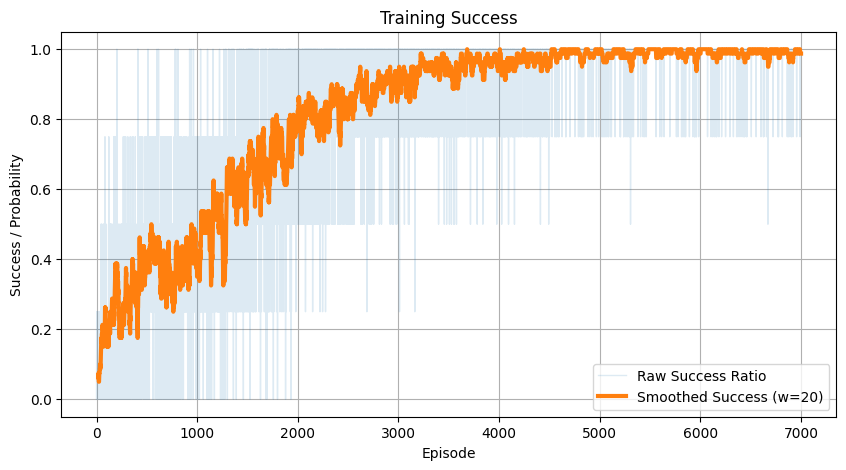

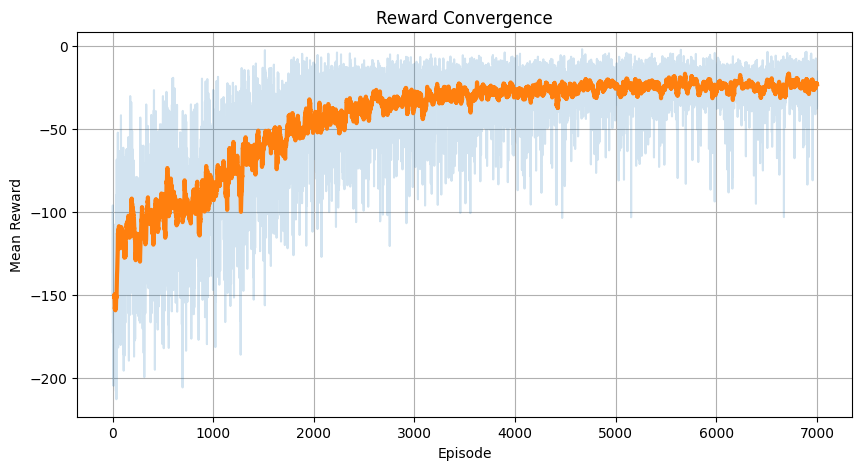

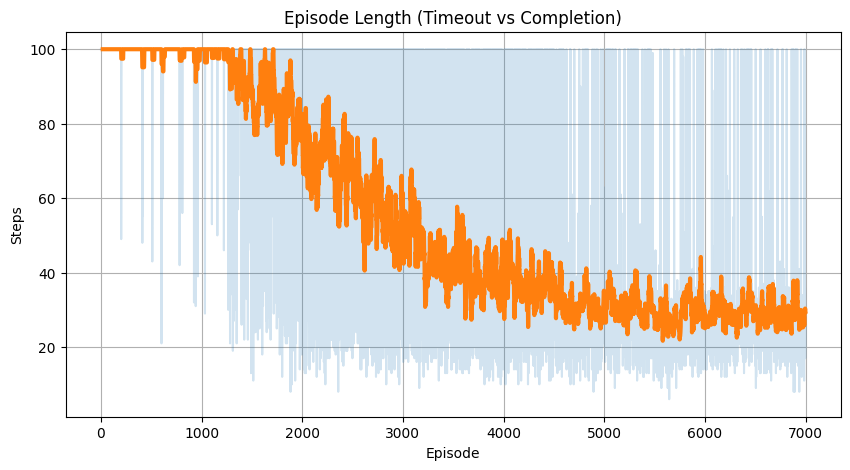

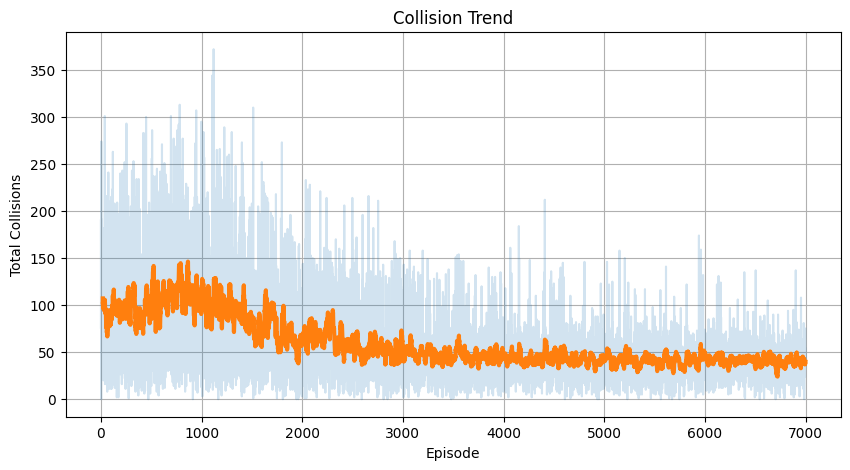

In [2]:
import csv
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# Helper: moving average
# ============================================================

def smooth(x, window=20):
    x = np.asarray(x, dtype=np.float32)

    if window <= 1 or len(x) < window:
        return x, np.arange(len(x))

    y = np.convolve(x, np.ones(window)/window, mode="valid")
    idx = np.arange(window-1, len(x))
    return y, idx


# ============================================================
# PAPER-STYLE PLOTTING
# ============================================================

def plot_tanet_td3_training(csv_path="2tanet_td3_train_log.csv", smooth_window=20):

    episodes = []
    success_ratio = []
    reached_count = []
    steps = []
    mean_reward = []
    collisions = []
    tanet_loss = []

    with open(csv_path, "r") as f:
        reader = csv.DictReader(f)

        for row in reader:
            episodes.append(int(row["episode"]))
            success_ratio.append(float(row["success_ratio"]))
            reached_count.append(float(row["reached_count"]))
            steps.append(float(row["steps"]))
            mean_reward.append(float(row["mean_reward"]))

            total_coll = (
                float(row["coll_uav_uav"]) +
                float(row["coll_uav_obs"]) +
                float(row["coll_uav_other_tgt"])
            )
            collisions.append(total_coll)

            tanet_loss.append(float(row["tanet_loss"]))

    episodes = np.array(episodes)

    # 🔥 Important metric
    success_all = (np.array(reached_count) == 4).astype(float)

    # smoothing
    succ_s, idx1 = smooth(success_ratio, smooth_window)
    all_s, idx2 = smooth(success_all, smooth_window)
    steps_s, idx3 = smooth(steps, smooth_window)
    reward_s, idx4 = smooth(mean_reward, smooth_window)
    coll_s, idx5 = smooth(collisions, smooth_window)
    loss_s, idx6 = smooth(tanet_loss, smooth_window)

    ep1 = episodes[idx1]
    ep2 = episodes[idx2]
    ep3 = episodes[idx3]
    ep4 = episodes[idx4]
    ep5 = episodes[idx5]
    ep6 = episodes[idx6]

    # ============================================================
    # FIGURE 1 — SUCCESS (same visual style as reward plot)
    # ============================================================

    plt.figure(figsize=(10,5))

    # raw as a faint line (NOT scatter)
    plt.plot(episodes, success_ratio, alpha=0.15, linewidth=1, label="Raw Success Ratio")

    # smoothed success ratio
    plt.plot(ep1, succ_s, linewidth=3, label=f"Smoothed Success (w={smooth_window})")

    # "ALL UAVs reached" is binary; plot ONLY its smoothed probability (moving avg)
    # plt.plot(ep2, all_s, linewidth=3, linestyle="--",
    # label=f"P(All reached) smoothed (w={smooth_window})")

    plt.ylim(-0.05, 1.05)
    plt.xlabel("Episode")
    plt.ylabel("Success / Probability")
    plt.title("Training Success")
    plt.grid(True)
    plt.legend()
    plt.show()



    # ============================================================
    # FIGURE 2 — REWARD
    # ============================================================

    plt.figure(figsize=(10,5))

    plt.plot(episodes, mean_reward, alpha=0.2)
    plt.plot(ep4, reward_s, linewidth=3)

    plt.xlabel("Episode")
    plt.ylabel("Mean Reward")
    plt.title("Reward Convergence")
    plt.grid(True)
    plt.show()


    # ============================================================
    # FIGURE 3 — STEPS
    # ============================================================

    plt.figure(figsize=(10,5))

    plt.plot(episodes, steps, alpha=0.2)
    plt.plot(ep3, steps_s, linewidth=3)

    plt.xlabel("Episode")
    plt.ylabel("Steps")
    plt.title("Episode Length (Timeout vs Completion)")
    plt.grid(True)
    plt.show()


    # ============================================================
    # FIGURE 4 — COLLISIONS
    # ============================================================

    plt.figure(figsize=(10,5))

    plt.plot(episodes, collisions, alpha=0.2)
    plt.plot(ep5, coll_s, linewidth=3)

    plt.xlabel("Episode")
    plt.ylabel("Total Collisions")
    plt.title("Collision Trend")
    plt.grid(True)
    plt.show()


    # # ============================================================
    # # FIGURE 5 — TANet LOSS
    # # ============================================================

    # plt.figure(figsize=(10,5))

    # plt.plot(episodes, tanet_loss, alpha=0.2)
    # plt.plot(ep6, loss_s, linewidth=3)

    # plt.xlabel("Episode")
    # plt.ylabel("Loss")
    # plt.title("TANet Training Loss")
    # plt.grid(True)
    # plt.show()
    
plot_tanet_td3_training(
    csv_path="tanet_td3_train_log.csv",
    smooth_window=20
)


In [7]:
# ============================================================
# FULL PAPER-FAITHFUL EVALUATION
# - Loads trained agents + TANet
# - Greedy actions (no exploration)
# - Assignment EVERY STEP
# - Prints success for EVERY episode
# - NEW: prints average success, steps, collisions at the end
# ============================================================

import csv
import pickle
import numpy as np
import torch


def evaluate_TANet_TD3(
    ckpt_path,
    episodes=200,
    seed=123,
    max_steps=100,
    eval_csv="tanet_td3_eval_log.csv",
    traj_pkl=None,
    device=None,
):

    # ------------------------------------------------
    # Build environment EXACTLY like training
    # ------------------------------------------------
    env = UAVBox3D_TANetTD3_Env(
        seed=seed,
        max_steps=max_steps,
        n_uavs=4,
        n_targets=4,
        n_obstacles=2,
        d_det=0.5,
        world_low=np.array([-1.0, -1.0, 0.0], dtype=np.float32),
        world_high=np.array([1.0, 1.0, 1.0], dtype=np.float32),
    )

    obs0, _ = env.reset(seed=seed)

    state_dim = env.observation_space[0].shape[0]
    action_dim = env.action_space[0].shape[0]
    max_action = float(env.action_space[0].high[0])

    # ------------------------------------------------
    # Recreate models
    # ------------------------------------------------
    agents = [TD3Agent(state_dim, action_dim, max_action, device=device)
              for _ in range(env.n_uavs)]

    tanet = TargetAssignmentNet(
        input_dim=state_dim,
        n_targets=env.n_targets
    ).to(agents[0].device)

    # ------------------------------------------------
    # Load checkpoint
    # ------------------------------------------------
    load_tanet_td3_checkpoint(
        ckpt_path,
        agents=agents,
        tanet=tanet,
        tanet_opt=None,
        device=agents[0].device
    )

    for ag in agents:
        ag.actor.eval()
        ag.critic.eval()

    tanet.eval()

    # ------------------------------------------------
    # CSV
    # ------------------------------------------------
    with open(eval_csv, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow([
            "episode",
            "success_ratio",
            "success_all",
            "reached_count",
            "steps",
            "mean_reward",
            "sum_reward",
            "collisions"
        ])

    # ------------------------------------------------
    # Optional trajectory storage
    # ------------------------------------------------
    traj_data = [] if traj_pkl is not None else None

    # ------------------------------------------------
    # NEW: accumulators for averages
    # ------------------------------------------------
    all_success_ratio = []
    all_success_all = []
    all_steps = []
    all_collisions = []

    print("\n========== STARTING EVALUATION ==========\n")

    # ============================================================
    # EVALUATION LOOP
    # ============================================================
    for ep in range(episodes):

        _canon_obs, _ = env.reset(seed=seed + ep)

        total_R = np.zeros(env.n_uavs, dtype=np.float32)
        last_info = {}

        # ----- initial TANet assignment
        x0 = np.stack([env._obs_i(i, assigned_first=False)
                       for i in range(env.n_uavs)], axis=0)

        x0_t = torch.FloatTensor(x0).to(agents[0].device)

        with torch.no_grad():
            probs = torch.softmax(tanet(x0_t), dim=1).cpu().numpy()

        mapping, _ = hungarian_from_scores(probs, maximize=True)
        apply_mapping_to_env(env, mapping)

        obs_seq = build_resequenced_obs(env)

        ep_frames = []

        # ------------------------------------------------
        # rollout
        # ------------------------------------------------
        for t in range(max_steps):

            # GREEDY ACTIONS
            actions = np.stack([
                agents[i].act(obs_seq[i], noise_scale=0.0)
                for i in range(env.n_uavs)
            ])

            _canon_next, rewards, terminated, truncated, info = env.step(actions)

            done = terminated or truncated
            last_info = info
            total_R += rewards

            # ----- TANet reassignment EVERY STEP
            x = np.stack([env._obs_i(i, assigned_first=False)
                          for i in range(env.n_uavs)], axis=0)

            x_t = torch.FloatTensor(x).to(agents[0].device)

            with torch.no_grad():
                probs = torch.softmax(tanet(x_t), dim=1).cpu().numpy()

            mapping, _ = hungarian_from_scores(probs, maximize=True)
            apply_mapping_to_env(env, mapping)

            obs_seq = build_resequenced_obs(env)

            if traj_data is not None:
                ep_frames.append(env.uav_pos.copy())

            if done:
                break

        # ============================================================
        # METRICS
        # ============================================================

        reached = last_info.get("reached", np.zeros(env.n_uavs))
        reached_count = int(np.sum(reached))

        success_ratio = reached_count / env.n_uavs
        success_all = int(reached_count == env.n_uavs)

        steps = last_info.get("step", max_steps)

        collisions = (
            last_info.get("coll_uav_uav", 0)
            + last_info.get("coll_uav_obs", 0)
            + last_info.get("coll_uav_other_tgt", 0)
        )

        mean_reward = float(np.mean(total_R))
        sum_reward = float(np.sum(total_R))

        # ------------------------------------------------
        # NEW: store for averages
        # ------------------------------------------------
        all_success_ratio.append(success_ratio)
        all_success_all.append(success_all)
        all_steps.append(steps)
        all_collisions.append(collisions)

        # ============================================================
        # PRINT EVERY EPISODE
        # ============================================================

        print(
            f"[EVAL] EP={ep:4d} | "
            f"Success={success_ratio:.2f} | "
            f"ALL={success_all} | "
            f"Reached={reached_count}/4 | "
            f"Steps={steps:3d} | "
            f"MeanR={mean_reward:+8.2f} | "
            f"Coll={collisions}",
            flush=True
        )

        # write CSV
        with open(eval_csv, "a", newline="") as f:
            writer = csv.writer(f)
            writer.writerow([
                ep,
                success_ratio,
                success_all,
                reached_count,
                steps,
                mean_reward,
                sum_reward,
                collisions
            ])

        if traj_data is not None:
            traj_data.append(ep_frames)

    # ------------------------------------------------
    # Save trajectories
    # ------------------------------------------------
    if traj_data is not None:
        with open(traj_pkl, "wb") as f:
            pickle.dump(traj_data, f)
        print(f"\nSaved trajectories -> {traj_pkl}")

    # ------------------------------------------------
    # NEW: final averages
    # ------------------------------------------------
    avg_success = float(np.mean(all_success_ratio))
    avg_success_all = float(np.mean(all_success_all))
    avg_steps = float(np.mean(all_steps))
    avg_collisions = float(np.mean(all_collisions))

    print("\n========== SUMMARY ==========")
    print(f"Avg success ratio : {avg_success:.4f}")
    print(f"Avg full success  : {avg_success_all:.4f}")
    print(f"Avg steps         : {avg_steps:.2f}")
    print(f"Avg collisions    : {avg_collisions:.2f}")

    print(f"\nSaved eval CSV -> {eval_csv}")
    print("\n========== EVALUATION COMPLETE ==========\n")

    return {
        "eval_csv": eval_csv,
        "traj_pkl": traj_pkl,
        "avg_success_ratio": avg_success,
        "avg_full_success": avg_success_all,
        "avg_steps": avg_steps,
        "avg_collisions": avg_collisions,
    }


# ============================================================
# RUN EVALUATION
# ============================================================

results = evaluate_TANet_TD3(
    ckpt_path="tanet_td3_baseline.pth",
    episodes=200,
    seed=2026,
    max_steps=100,
    eval_csv="tanet_td3_eval_log.csv",
    #traj_pkl="tanet_td3_eval_traj.pkl",  # optional
)

print(results)


========== STARTING EVALUATION ==========

[EVAL] EP=   0 | Success=1.00 | ALL=1 | Reached=4/4 | Steps= 11 | MeanR=   -8.15 | Coll=20
[EVAL] EP=   1 | Success=1.00 | ALL=1 | Reached=4/4 | Steps= 11 | MeanR=   -6.07 | Coll=10
[EVAL] EP=   2 | Success=1.00 | ALL=1 | Reached=4/4 | Steps= 31 | MeanR=  -34.55 | Coll=44
[EVAL] EP=   3 | Success=1.00 | ALL=1 | Reached=4/4 | Steps= 17 | MeanR=  -17.74 | Coll=43
[EVAL] EP=   4 | Success=1.00 | ALL=1 | Reached=4/4 | Steps= 28 | MeanR=  -25.49 | Coll=42
[EVAL] EP=   5 | Success=1.00 | ALL=1 | Reached=4/4 | Steps= 24 | MeanR=  -38.87 | Coll=89
[EVAL] EP=   6 | Success=0.75 | ALL=0 | Reached=3/4 | Steps=100 | MeanR=  -54.62 | Coll=32
[EVAL] EP=   7 | Success=1.00 | ALL=1 | Reached=4/4 | Steps= 31 | MeanR=  -29.79 | Coll=31
[EVAL] EP=   8 | Success=1.00 | ALL=1 | Reached=4/4 | Steps= 30 | MeanR=  -17.26 | Coll=15
[EVAL] EP=   9 | Success=1.00 | ALL=1 | Reached=4/4 | Steps= 22 | MeanR=  -16.67 | Coll=27
[EVAL] EP=  10 | Success=1.00 | ALL=1 | Reache

In [1]:
# ============================
# LOAD TANET-TD3 SUMMARY ONLY
# ============================

import csv
import numpy as np

def load_tanet_summary_from_csv(csv_path):
    rows = []
    with open(csv_path, "r", newline="") as f:
        reader = csv.DictReader(f)
        for row in reader:
            rows.append(row)

    avg_success_ratio = float(np.mean([float(r["success_ratio"]) for r in rows]))
    avg_full_success  = float(np.mean([float(r["success_all"]) for r in rows]))
    avg_steps         = float(np.mean([float(r["steps"]) for r in rows]))
    avg_collisions    = float(np.mean([float(r["collisions"]) for r in rows]))

    results = {
        "eval_csv": csv_path,
        "avg_success_ratio": avg_success_ratio,
        "avg_full_success": avg_full_success,
        "avg_steps": avg_steps,
        "avg_collisions": avg_collisions,
    }
    return results

results_loaded = load_tanet_summary_from_csv("tanet_td3_eval_log.csv")
print(results_loaded)

{'eval_csv': 'tanet_td3_eval_log.csv', 'avg_success_ratio': 0.98125, 'avg_full_success': 0.925, 'avg_steps': 28.945, 'avg_collisions': 38.635}
